In [1]:
%load_ext autoreload
%autoreload 2

%load_ext jupyter_ai_magics

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import pickle
from tqdm import tqdm

from cgnn import process_data

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import subgraph

import torch


# Process and visualize data

## Case + death data

In [ ]:
death_df, case_df = process_data.process_case_death_data()

unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3


In [ ]:
fig, axs = plt.subplots(2, figsize=(10,12), sharex=True)

for c in tqdm(case_df['CBSA'].unique()):
    axs[0].plot(case_df.loc[case_df['CBSA'] == c, 'date'], case_df.loc[case_df['CBSA'] == c, 'CASE_COUNT_7DAY_AVG'].values, '-', label='case counts 7 day avg', alpha=0.1, color='dodgerblue')
    axs[1].plot(death_df.loc[death_df['CBSA'] == c, 'date'], death_df.loc[death_df['CBSA'] == c, 'DEATH_COUNT_7DAY_AVG'].values, '-', label='death counts 7 day avg', alpha=0.1, color='firebrick')

axs[0].set_title('case counts 7 day avg')
axs[1].set_title('death counts 7 day avg')

plt.xticks(rotation=45)

## Google mobility data

In [5]:
import process_data

mobility_report_df = process_data.process_mobility_report()
mobility_report_df.head()

unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
imputing using columns ['retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']
Percent of variation explained with first component: 76.10792683627832 %
[0.76107927 0.10546504 0.09323786 0.03661961 0.00359822]
Reading population data from https://www2.census.gov/programs-surveys/popest/datasets/2020-2023/counties/totals/co-est2023-alldata.csv


,date,CBSA,mobility_pc1_full_dat,mobility_pc2_full_dat,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
0,2020-03-02,10100,15.980166,14.422821,4.000000,0.000000,NaN,3.000000,-1.0
1,2020-03-02,10140,26.318889,13.783579,13.000000,12.000000,14.0,1.000000,0.0
2,2020-03-02,10180,28.134036,9.186371,8.658451,5.858545,NaN,1.953405,NaN
3,2020-03-02,10220,33.359232,11.574745,19.000000,0.000000,NaN,4.000000,-2.0
4,2020-03-02,10300,18.882796,12.984239,7.000000,0.000000,NaN,2.000000,-1.0


## Safegraph data

In [6]:
%%time
mobility_df = process_data.get_safegraph_mobility_data()

CPU times: user 24 s, sys: 3.82 s, total: 27.8 s
Wall time: 27.8 s


## Process data for pytorch-geometric

In [44]:
%%time
import torch
from cgnn import process_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("processing data on device:", device)

version = "gcn-usa-2020-22-fix-delta-no-temporal-edges"
data = process_data.create_torch_geometric_data(version, device, include_temporal_edges=False)

processing data on device: cuda
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
rows with neg cases: 63756 out of 137850
rows with neg deaths: 44188 out of 139350
unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
imputing using columns ['retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']
Percent of variation explained with first component: 76.10792683627832 %
[0.76107927 0.10546504 0.09323786 0.03661961 0.00359822]
Reading population data from https://www2.census.gov/programs-surveys/popest/datasets/2020-2023/counties/totals/co-est2023-alldata.csv
creating coo_df
Creating spatial edges...


Spatial Edges: 100%|██████████| 1018684/1018684 [00:46<00:00, 22101.99it/s]


1018684 spatial edges
processing safegraph data
Processing edge weights...


100%|██████████| 1018684/1018684 [00:00<00:00, 1358902.81it/s]


Processed data saved to ../data/processed/gcn-usa-2020-22-fix-delta-no-temporal-edges/
CPU times: user 8min 50s, sys: 10min 17s, total: 19min 7s
Wall time: 6min 24s


In [45]:
torch.save(data, f"../data/processed/{version}/data.pt")

In [3]:
import torch
from cgnn import process_data

version = "gcn-usa-2020-22"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = torch.load(f"../data/processed/{version}/data.pt")
data = data.to(device)

In [4]:
data

Data(x=[135864, 16], edge_index=[2, 1153630], y=[135864], edge_weight=[1153630], train_mask=[135864], test_mask=[135864])

# Check edges are done properly

In [5]:
with open(f"../data/processed/{version}/node_dict.pkl", "rb") as file:
    node_dict = pickle.load(file)

In [6]:
swapped_node_dict = {value: key for key, value in node_dict.items()}

In [7]:
# for i, edge in tqdm(enumerate(torch.transpose(data.edge_index, 0, 1))):
#     orig_node = swapped_node_dict[edge[0].cpu().numpy().item()]
#     dest_node = swapped_node_dict[edge[1].cpu().numpy().item()]
    
#     orig_fips = orig_node.split("-")[0]
#     dest_fips = dest_node.split("-")[0]
    
#     orig_date = pd.to_datetime("-".join(orig_node.split("-")[1:]))
#     dest_date = pd.to_datetime("-".join(dest_node.split("-")[1:]))
    
#     # check that that if date is diff, then the fips is same and its from old to new
#     if orig_date != dest_date:
#         assert orig_fips == dest_fips, f"temporal edge, {orig_node}, {dest_node} diff fips"
#         assert orig_date < dest_date, f"temporal edge, {orig_node}, {dest_node} wrong direction"
        

# Train model

##  GCN

In [51]:
from tqdm import tqdm
from cgnn.model import GCN, RMSLELoss
from torch_geometric.nn import summary

graph = data.to(device)
print(graph)

model     = GCN().to(device)
print(summary(model, graph.x, graph.edge_index, graph.edge_weight))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=5e-4)
criterion = RMSLELoss()

def train():
	model.train()
	optimizer.zero_grad()
	out = model(graph.x.to(device), graph.edge_index.to(device), graph.edge_weight.to(device))
	loss = criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask])
	loss.backward()
	optimizer.step()
	return loss

def test():
	model.eval()
	out = model(graph.x, graph.edge_index, graph.edge_weight)
	loss = criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask])

	return loss

train_loss = []
test_loss = []
for epoch in tqdm(range(5_000)):
	loss = train()
	train_loss.append(loss.cpu().detach().numpy())
	loss = test()
	test_loss.append(loss.cpu().detach().numpy())

print("final test loss: {}".format(test_loss[-1]))

Data(x=[135864, 16], edge_index=[2, 1018684], y=[135864], edge_weight=[1018684], train_mask=[135864], test_mask=[135864])
+---------------------+---------------------------------------+----------------+----------+
| Layer               | Input Shape                           | Output Shape   | #Param   |
|---------------------+---------------------------------------+----------------+----------|
| GCN                 | [135864, 16], [2, 1018684], [1018684] | [135864, 1]    | 3,745    |
| ├─(MLP_embed)Linear | [135864, 16]                          | [135864, 32]   | 544      |
| ├─(conv1)GCNConv    | [135864, 32], [2, 1018684], [1018684] | [135864, 32]   | 1,056    |
| ├─(conv2)GCNConv    | [135864, 64], [2, 1018684], [1018684] | [135864, 32]   | 2,080    |
| ├─(MLP_pred)Linear  | [135864, 64]                          | [135864, 1]    | 65       |
+---------------------+---------------------------------------+----------------+----------+


100%|██████████| 5000/5000 [01:37<00:00, 51.24it/s]

final test loss: 0.49996912479400635


In [52]:
import os

model_save_dir = f"models/gcn_checkpoints/{version}"
os.makedirs(model_save_dir, exist_ok=True)

model_path = os.path.join(model_save_dir, "gcn_final_model.pt")

torch.save({
    'epoch': 5000, # Or the actual last epoch number
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_loss[-1],
    'test_loss': test_loss[-1],
    # You can save other information here, like hyperparameters
}, model_path)

In [10]:
import torch
from cgnn.model import GCN 

graph = data.to(device)

model = GCN().to(device)

model_path = "models/gcn_checkpoints/gcn_final_model.pt"
checkpoint = torch.load(model_path)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [11]:
model.eval()
out = model(graph.x, graph.edge_index, graph.edge_weight)
print("train loss", criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask]))
print("test loss", criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask]))
print("train corr", torch.corrcoef(torch.stack((out[graph.train_mask].squeeze(), graph.y[graph.train_mask])))[0,1])
print("test corr", torch.corrcoef(torch.stack((out[graph.test_mask].squeeze(), graph.y[graph.test_mask])))[0,1])
y_test = graph.y[graph.test_mask].cpu().numpy()
out_test = out[graph.test_mask].detach().cpu().numpy()

y_train = graph.y[graph.train_mask].cpu().numpy()
out_train = out[graph.train_mask].detach().cpu().numpy()

NameError: name 'criterion' is not defined

In [ ]:
fig, ax = plt.subplots()

ax.plot(train_loss, label='training loss')
ax.plot(test_loss, label='test loss')
ax.set_xlabel('epoch')
ax.set_ylabel('RMSLE')
ax.grid()
ax.legend()

In [ ]:
fig, ax = plt.subplots()
ax.plot(y_train, out_train, '.')
ax.axline((0, 0), slope=1., color='red')
ax.grid()
ax.set_xlabel('truth')
ax.set_ylabel('prediction')
ax.set_title('Training set')

In [ ]:
fig, ax = plt.subplots()
ax.plot(y_test, out_test, '.')
ax.axline((0, 0), slope=1., color='red')
ax.grid()
ax.set_xlabel('truth')
ax.set_ylabel('prediction')
ax.set_title('Test set')

In [ ]:
node_dict = process_data.create_node_key()

pred_df = pd.DataFrame()
pred_df['key'] = np.array(list(node_dict.keys()))[np.where(np.array(graph.test_mask.cpu().numpy())==1)]
pred_df['truth'] = y_test
pred_df['pred'] = out_test

pred_df[['fips','date']] = pred_df['key'].str.split('-',n=1, expand=True)
pred_df['date'] = pd.to_datetime(pred_df['date'])

train_df = pd.DataFrame()
train_df['key'] = np.array(list(node_dict.keys()))[np.where(np.array(graph.train_mask.cpu().numpy())==1)]
train_df['truth'] = y_train
train_df['pred'] = out_train

train_df[['cbsa','date']] = train_df['key'].str.split('-',n=1, expand=True)
train_df['date'] = pd.to_datetime(train_df['date'])

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

ax.plot(train_df.groupby('date')[['truth', 'pred']].sum(), '.-', alpha = 0.25)

ax.plot(pred_df.groupby('date')[['truth']].sum(), '.-', color='steelblue', label='Truth')
ax.plot(pred_df.groupby('date')[['pred']].sum(), '.-', color='orange', label='Prediction')
ax.legend(loc='upper left', fontsize=10)

ax.set_ylabel('National Case Counts', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')

fig.suptitle('GCN predictions',
             fontsize=18,
             fontweight='bold')

fig.autofmt_xdate(rotation=45)
plt.tight_layout()

# GNNExplainer

In [ ]:
with open("../data/processed/gcn-usa-2020-22/node_dict.pkl", "rb") as file:
    node_dict = pickle.load(file)

In [ ]:
from datetime import datetime

def get_mask(target_date, node_dict, prev_weeks=None):
    # get node_dict
    def get_values_by_date(data_dict, target_date):
        filtered_values = []
        for key, value in data_dict.items():
            if target_date in key:
                filtered_values.append(value)
        return filtered_values
    
    target_idxs = get_values_by_date(node_dict, target_date)
    assert len(target_idxs) > 0, f"target_idxs empty for {target_date}"
    
    target_idxs = torch.tensor(target_idxs).to(device)
    
    # historical_nodes = torch.arange(max(target_idxs), device=device)
    historical_nodes = []
    for node_key, node_idx in node_dict.items():
        date_parts = node_key.split('-')[1:]
        node_date_str = "-".join(date_parts)
        node_date = datetime.strptime(node_date_str, "%Y-%m-%d")
    
        if node_date <= datetime.strptime(target_date, "%Y-%m-%d"):
            if prev_weeks:
                # check that node is within certain number of weeks of target date
                diff = datetime.strptime(target_date, "%Y-%m-%d") - node_date
                if diff.days // 7 <= prev_weeks:
                    historical_nodes.append(node_idx)
            else:
                historical_nodes.append(node_idx)
    historical_nodes = torch.tensor(historical_nodes, dtype=torch.long).to(device)
    
    sub_edge_index, sub_edge_weight  = subgraph(
        subset=historical_nodes,
        edge_index=data.edge_index,
        edge_attr=data.edge_weight,
        relabel_nodes=True,
        return_edge_mask=False
    )
    sub_x = data.x[historical_nodes]

    target_node_map = {original_idx.item(): new_idx for new_idx, original_idx in enumerate(historical_nodes)}
    relabeled_target_idxs = torch.tensor([target_node_map[idx.item()] for idx in target_idxs]).to(device)

    return sub_x, sub_edge_index, sub_edge_weight, relabeled_target_idxs, historical_nodes


def get_explaination(target_date, prev_weeks=None):
    explainer = Explainer(
        model=model.cpu(),
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',
            task_level='node',
            return_type='raw',
        ),
    )
    # sub_x: data x historical_nodes_idx
    
    sub_x, sub_edge_index, sub_edge_weight, target_idxs, historical_nodes = get_mask(target_date, node_dict, prev_weeks)
    assert all(idx <= sub_x.shape[0] for idx in target_idxs), f"Some target idx out of bounds: {target_idxs}, sub_x.shape={sub_x.shape}"

    explanation = explainer(
        x=sub_x.to("cpu"),
        edge_index=sub_edge_index.to("cpu"),
        edge_weight=sub_edge_weight.to("cpu"),
        index=target_idxs.to("cpu"),
    )
    
    print("average explainable edge mask:", explanation.edge_mask.mean())
    
    subgraph_edges = sub_edge_index[:,explanation.edge_mask > 0.5]
    original_subgraph_edges = historical_nodes.cpu()[subgraph_edges.cpu()]
    
    print("number of edges in edge mask:", original_subgraph_edges.shape[1])
    print("number of self edges:", sum(original_subgraph_edges[0,:] == original_subgraph_edges[1,:]))
    print("number of inter edges:", sum(original_subgraph_edges[0,:] != original_subgraph_edges[1,:]))
    print("number of temporal edges:")

    return explanation, original_subgraph_edges

In [ ]:
%%time
mobility_df = process_data.get_safegraph_mobility_data()

mobility_df['key'] = mobility_df['cbsa_orig'] + "-" + mobility_df['date_range_start'].dt.strftime('%Y-%m-%d') + "-" + \
    mobility_df['cbsa_dest'] + "-" + pd.to_datetime(mobility_df['date_range_start']).dt.strftime('%Y-%m-%d')

# merge lat and long into to mobility df
cbsa_lat_long_df = pd.read_csv('../data/raw/2024_Gaz_cbsa_national.csv', dtype={
        "GEOID": "str",
})

mobility_df = mobility_df.merge(cbsa_lat_long_df[["GEOID", "INTPTLAT", "INTPTLONG"]], left_on="cbsa_orig", right_on="GEOID", how="left").drop("GEOID", axis=1).rename(
    columns={"INTPTLAT":"LATITUDE_orig", "INTPTLONG":"LONGITUDE_orig"}
)

mobility_df = mobility_df.merge(cbsa_lat_long_df[["GEOID", "INTPTLAT", "INTPTLONG"]], left_on="cbsa_dest", right_on="GEOID", how="left").drop("GEOID", axis=1).rename(
    columns={"INTPTLAT":"LATITUDE_dest", "INTPTLONG":"LONGITUDE_dest"}
)

mobility_df["log_visitor_home_aggregation"] = np.log(mobility_df["visitor_home_aggregation"])

In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.geometry import MultiPolygon, Polygon

def plot_safegraph(subset_df, target_date, land_color='white', tristate_color='#ccebc5', other_state_color='#f0f0f0'):
    """
    Generates a plot of mobility data

    Args:
        subset_df (pd.DataFrame): DataFrame containing mobility data with columns:
                                   'LATITUDE_orig', 'LONGITUDE_orig',
                                   'LATITUDE_dest', 'LONGITUDE_dest',
                                   'log_visitor_home_aggregation'.
        land_color (str): Color for the land masses.
        tristate_color (str): Fill color for NY, NJ, and PA.
        other_state_color (str): Fill color for other states.

    Returns:
        matplotlib.figure.Figure: The generated Matplotlib figure object.
    """
    # Ensure data is sorted for consistent plotting (optional, but can help if overlap matters)
    subset_df = subset_df.sort_values('log_visitor_home_aggregation')

    # --- Figure Setup ---
    fig = plt.figure(figsize=(10, 8), dpi=300)
    platecarree = ccrs.PlateCarree() # Projection for lat/lon data
    geodetic = ccrs.Geodetic()       # Projection for distance calculations (if needed)

    ax = fig.add_subplot(1, 1, 1, projection=platecarree)
    ax.set_extent([-135, -60, 20, 55], platecarree)

    # --- Add Geographic Features ---

    # Add Land with specified color
    ax.add_feature(cfeature.LAND, facecolor=land_color, edgecolor='black', linewidth=0.3, zorder=0)
    ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='gray', zorder=5)

    # Add Ocean and Lakes
    ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'], zorder=1)
    # ax.add_feature(cfeature.LAKES, facecolor=cfeature.COLORS['water'], edgecolor='black', linewidth=0.3, zorder=1)

    # Add Coastline
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black', zorder=3)

    # --- Plot Mobility Data ---
    def _plot_row_movement(row, platecarree, geodetic, sm):
        """Plots the movement for a single row of the DataFrame."""
        lat_orig = row['LATITUDE_orig']
        lon_orig = row['LONGITUDE_orig']
        lat_dest = row['LATITUDE_dest']
        lon_dest = row['LONGITUDE_dest']

        # Transform points only if necessary (already in PlateCarree for plotting)
        # lon_orig_proj, lat_orig_proj = platecarree.transform_point(lon_orig, lat_orig, geodetic)
        # lon_dest_proj, lat_dest_proj = platecarree.transform_point(lon_dest, lat_dest, geodetic)

        mob = row['log_visitor_home_aggregation']

        # Check for self-loops (origin == destination)
        # Use a small tolerance for floating point comparison
        if abs(lon_orig - lon_dest) < 1e-6 and abs(lat_orig - lat_dest) < 1e-6:
            ax.plot(lon_orig, lat_orig, marker='o',
                    markerfacecolor='blue', # Color by magnitude
                    markeredgecolor='none', # No edge for cleaner look
                    markersize=np.sqrt(mob), # Scale size non-linearly? Adjust as needed
                    transform=platecarree,
                    alpha=0.7, zorder=5)
        else:
            # Plot movement lines
            color = sm.to_rgba(mob)
            # Scale linewidth (tanh saturates, consider linear or sqrt scaling)
            linewidth = np.sqrt(max(0, mob - subset_df['log_visitor_home_aggregation'].min() + 1)) * 0.5 # Example scaling
            linewidth = max(0.1, linewidth) # Ensure minimum linewidth

            # ax.plot([lon_orig, lon_dest], [lat_orig, lat_dest],
            #          color=color,
            #          linewidth=linewidth,
            #          transform=platecarree,
            #          solid_capstyle='round',
            #          alpha=0.8,
            #          zorder=4)

            ax.annotate(
                '',
                xy=(lon_dest, lat_dest),
                xycoords=platecarree,
                xytext=(lon_orig, lat_orig),
                textcoords=platecarree,
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=linewidth,
                    alpha=0.8,
                    shrinkA=1, shrinkB=5
                ),
                zorder=7,
            )

    # --- Color Mapping for Lines ---
    # Filter out self-loops for normalization if they exist and are handled differently
    non_self_loops = subset_df[
        (abs(subset_df['LATITUDE_orig'] - subset_df['LATITUDE_dest']) > 1e-6) |
        (abs(subset_df['LONGITUDE_orig'] - subset_df['LONGITUDE_dest']) > 1e-6)
    ]

    if not non_self_loops.empty:
        min_val = non_self_loops['log_visitor_home_aggregation'].min()
        max_val = non_self_loops['log_visitor_home_aggregation'].max()
        # Handle case where min and max are the same
        if min_val == max_val:
             norm = plt.Normalize(vmin=min_val - 1, vmax=max_val + 1) # Adjust range slightly
        else:
             norm = plt.Normalize(vmin=min_val, vmax=max_val)

        custom_cmap = plt.cm.viridis # Or choose another perceptually uniform colormap like 'plasma', 'cividis'
        sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
        sm.set_array([]) # Important for standalone colorbar

        # Iterate and plot each movement line
        for index, row in subset_df.iterrows():
            _plot_row_movement(row, platecarree, geodetic, sm)

        # Add Colorbar
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8)
        cbar.set_label(r'$\log_{10}$ Visitor Home Aggregation', fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    else:
        print("No non-self-loop data to plot lines for.")


    # --- Final Touches ---
    ax.set_title(f"Explainable Subgraph, target_date:{target_date}", fontsize=14, pad=10)

    plt.tight_layout()

    return fig


In [58]:
self_edge_count = []
inter_edge_count = []
PREV_WEEKS = 4

# explain_dates = pd.date_range(start="2020-05-04", end="2022-12-31", freq='W-MON')
explain_dates = pd.date_range(start="2020-05-04", end="2020-06-30", freq='W-MON')


explaination_dict = {}

# with PdfPages('explainable_subgraph.pdf') as pdf:
with PdfPages('test.pdf') as pdf:
    for target_date in tqdm(explain_dates):
        target_date = target_date.strftime('%Y-%m-%d')
        print(target_date)
        explanation, subgraph_edges = get_explaination(target_date, prev_weeks=PREV_WEEKS)
        explaination_dict[target_date] = subgraph_edges
        
        # count types of edges
        self_edge_count.append(sum(subgraph_edges[0,:] == subgraph_edges[1,:]).cpu().numpy())
        inter_edge_count.append(sum(subgraph_edges[0,:] != subgraph_edges[1,:]).cpu().numpy())
    
        # create key
        swapped_dict = {value: key for key, value in node_dict.items()}
        node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
        node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
        explainable_keys = [node_idx_start[i] + "-" + node_idx_end[i] for i in range(len(node_idx_end))]
        explainable_mobility_df = mobility_df[mobility_df["key"].isin(explainable_keys)]
    
        print(explainable_mobility_df.groupby("date_range_start").size())
    
        # plot
        fig = plot_safegraph(explainable_mobility_df, target_date)
        pdf.savefig(fig)
        plt.close(fig)

  0%|          | 0/35 [00:00<?, ?it/s]

2020-05-04
average explainable edge mask: tensor(0.0769)
number of edges in edge mask: 288
number of self edges: tensor(40)
number of inter edges: tensor(248)
date_range_start
2020-04-06    29
2020-04-13    21
2020-04-20    34
2020-04-27    35
2020-05-04    41
dtype: int64


  3%|▎         | 1/35 [00:19<10:48, 19.06s/it]

2020-05-11
average explainable edge mask: tensor(0.0719)
number of edges in edge mask: 135
number of self edges: tensor(10)
number of inter edges: tensor(125)
date_range_start
2020-04-13     8
2020-04-20    14
2020-04-27    10
2020-05-04    10
2020-05-11     7
dtype: int64


  6%|▌         | 2/35 [00:25<06:28, 11.79s/it]

...

 94%|█████████▍| 33/35 [11:36<01:33, 46.60s/it]

2020-12-21
average explainable edge mask: tensor(0.1011)
number of edges in edge mask: 1763
number of self edges: tensor(232)
number of inter edges: tensor(1531)
date_range_start
2020-11-23    305
2020-11-30    266
2020-12-07    265
2020-12-14    284
2020-12-21    305
dtype: int64


 97%|█████████▋| 34/35 [12:08<00:42, 42.32s/it]

2020-12-28
average explainable edge mask: tensor(0.0889)
number of edges in edge mask: 1041
number of self edges: tensor(120)
number of inter edges: tensor(921)
date_range_start
2020-11-30    142
2020-12-07    154
2020-12-14    156
2020-12-21    154
2020-12-28    182
dtype: int64


100%|██████████| 35/35 [12:29<00:00, 21.41s/it]


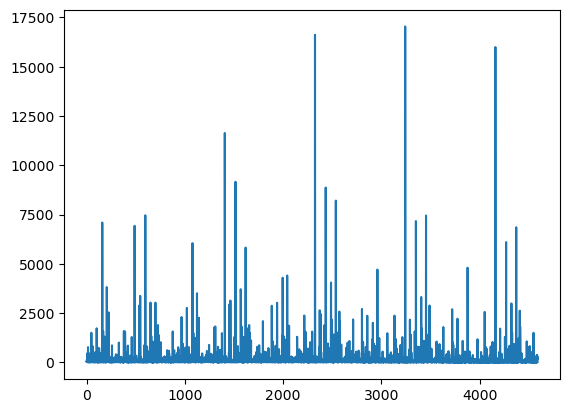

In [78]:
plt.plot(explanation.prediction)

# GNNExplainer Plots

In [28]:
explain_count_df = pd.DataFrame({
    'date': explain_dates,
    'self_edge_count': self_edge_count,
    'inter_edge_count': inter_edge_count,
})

explain_count_df['total_edge_count'] = explain_count_df['self_edge_count'] + explain_count_df['inter_edge_count']
explain_count_df['prop_self'] = explain_count_df['self_edge_count'] / explain_count_df['total_edge_count']

In [20]:
# explain_count_df.to_csv("explain_count.csv", index=False)

explain_count_df = pd.read_csv("explain_count.csv")
explain_dates = pd.date_range(start="2020-05-04", end="2022-12-31", freq='W-MON')

In [31]:
explain_count_df['date'] = pd.to_datetime(explain_count_df['date'])


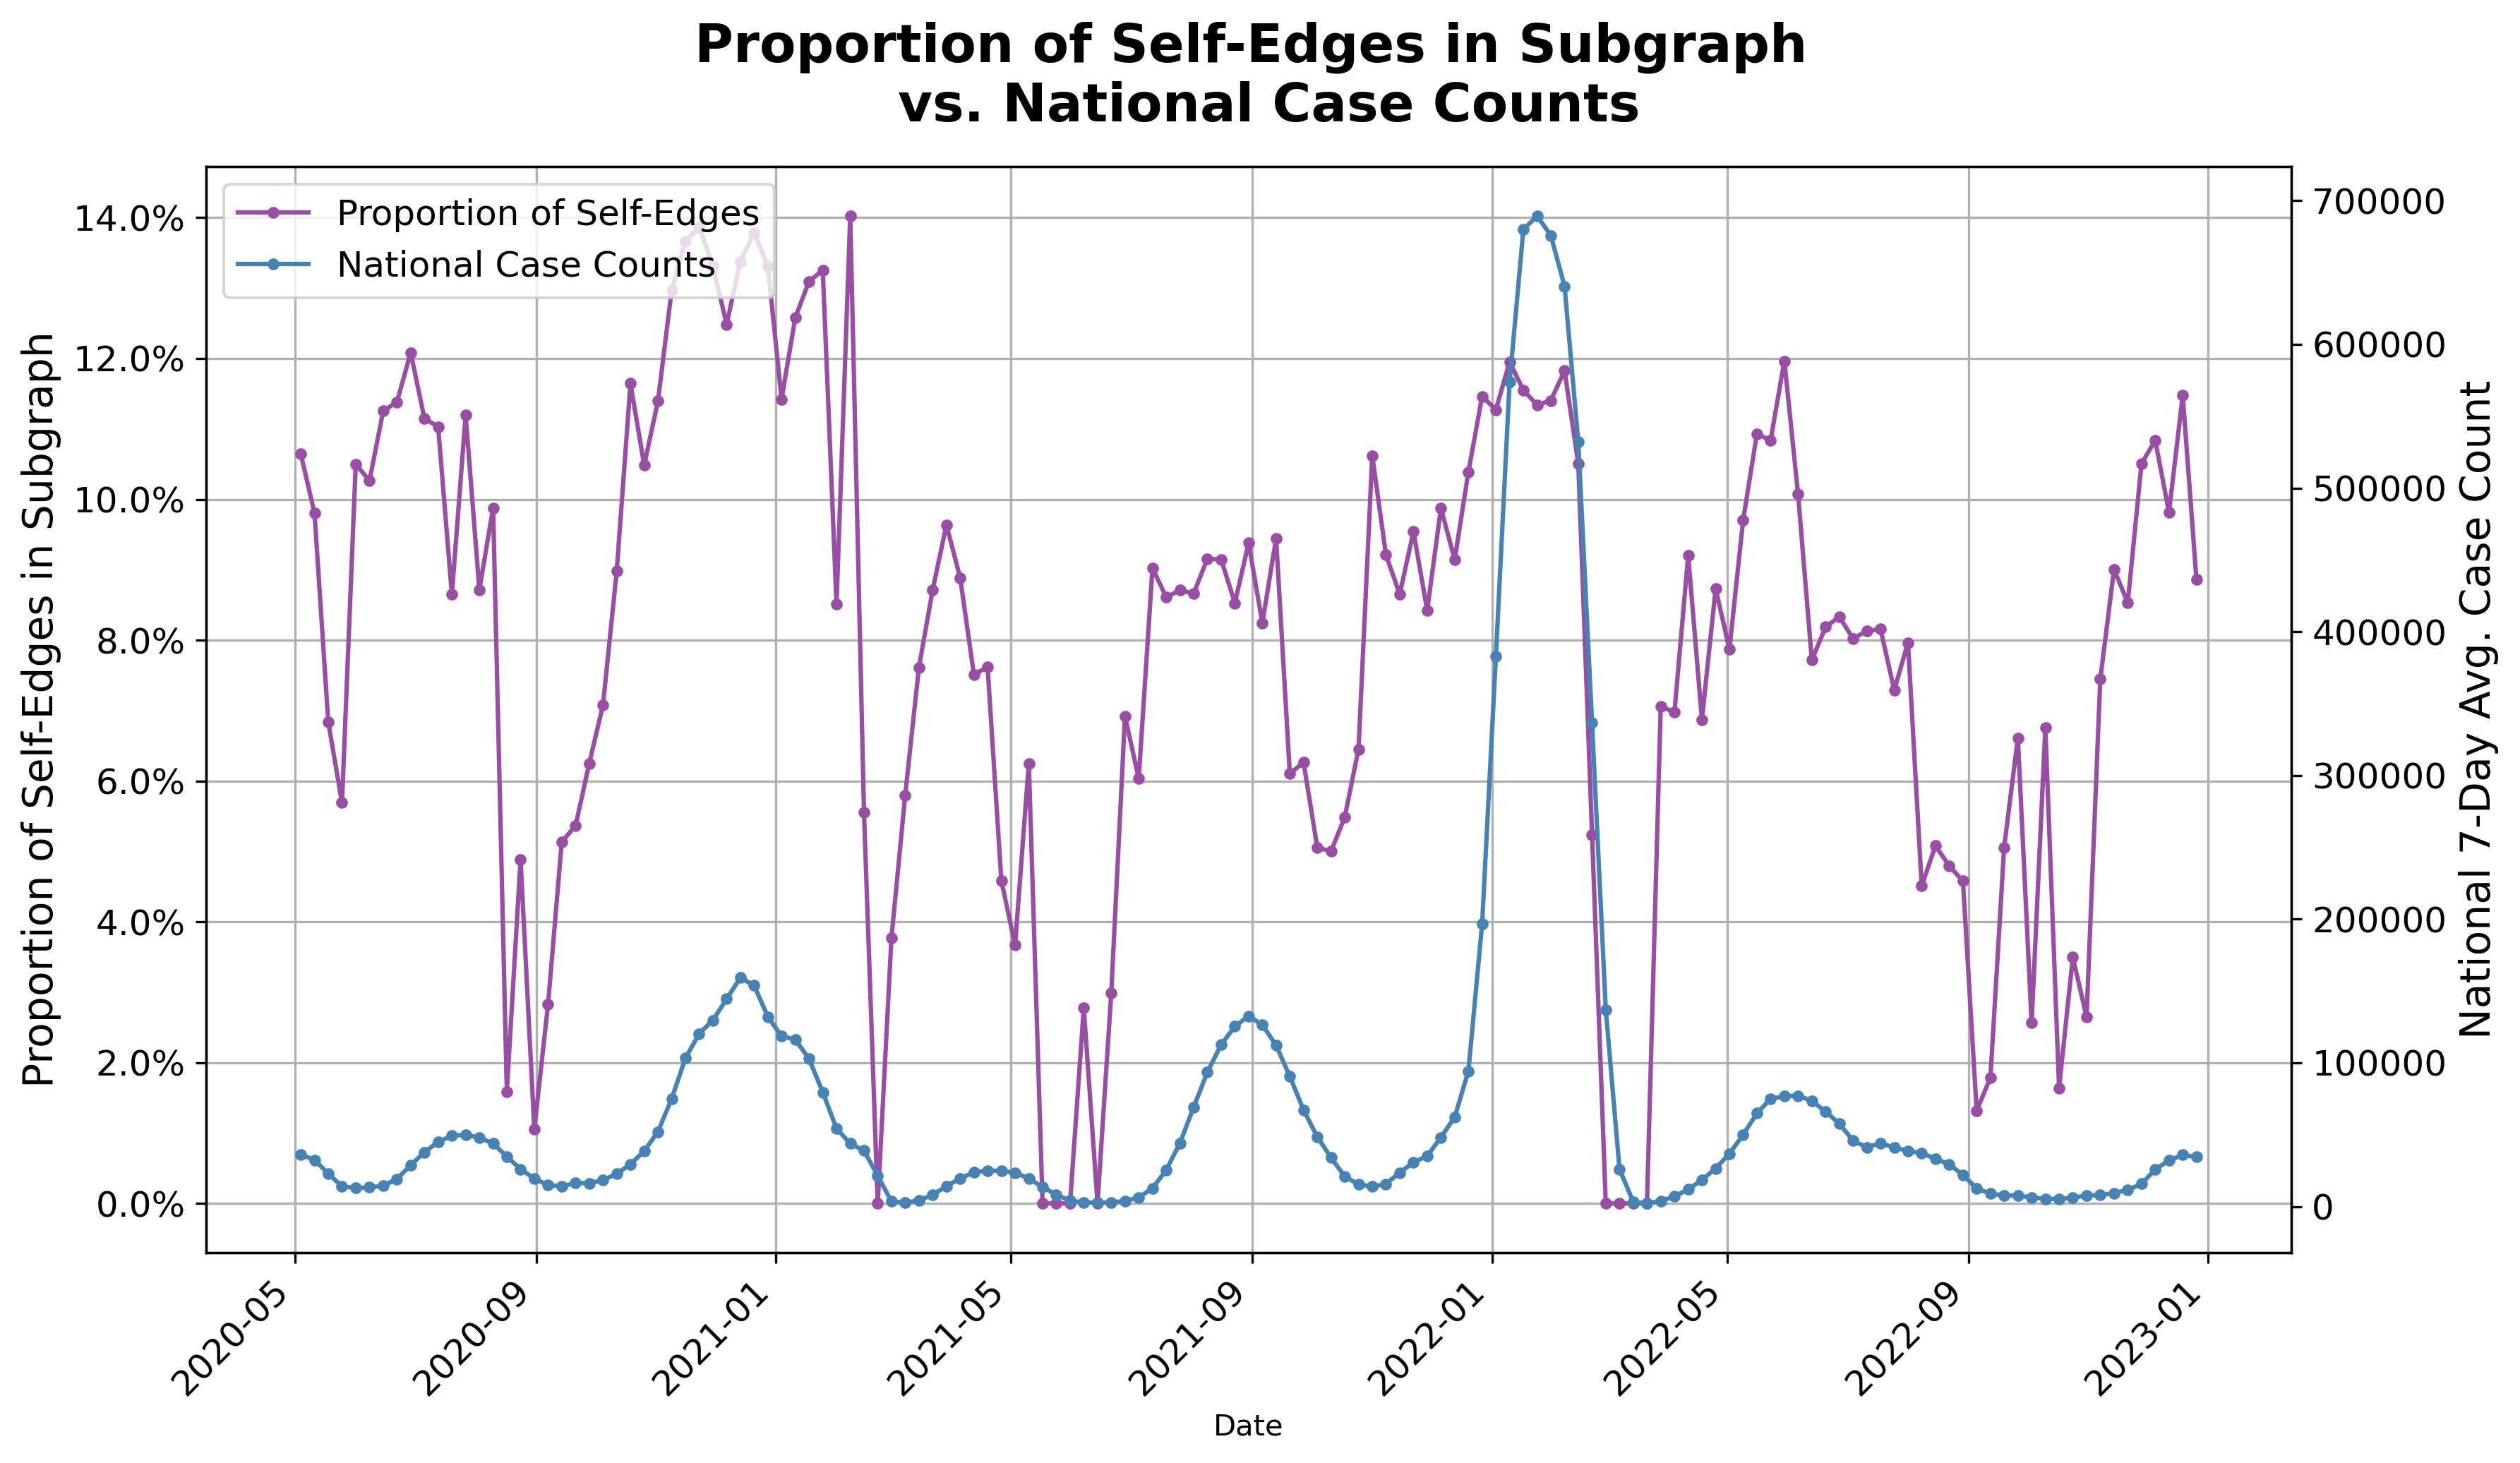

In [32]:
from matplotlib.ticker import PercentFormatter # Import the formatter

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

sub_case_df = case_df.loc[case_df['date'].isin(explain_dates)].groupby('date')[['CASE_COUNT_7DAY_AVG']].sum().reset_index()

line1, = ax.plot(explain_count_df['date'], explain_count_df['prop_self'], '.-', label='Proportion of Self-Edges', color='#984ea3')
ax.set_ylabel('Proportion of Self-Edges in Subgraph', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

ax2 = ax.twinx()
line2, = ax2.plot(
    sub_case_df['date'],
    sub_case_df['CASE_COUNT_7DAY_AVG'],
    ".-",
    color='steelblue',
    label='National Case Counts' # More descriptive label
)
ax2.set_ylabel('National 7-Day Avg. Case Count', fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)

ax.legend(handles=[line1, line2], loc='upper left', fontsize=12)

fig.suptitle('Proportion of Self-Edges in Subgraph \n vs. National Case Counts',
             fontsize=18,
             fontweight='bold')


fig.autofmt_xdate(rotation=45)
plt.tight_layout()

# plt.savefig("explain_self_prop.png")


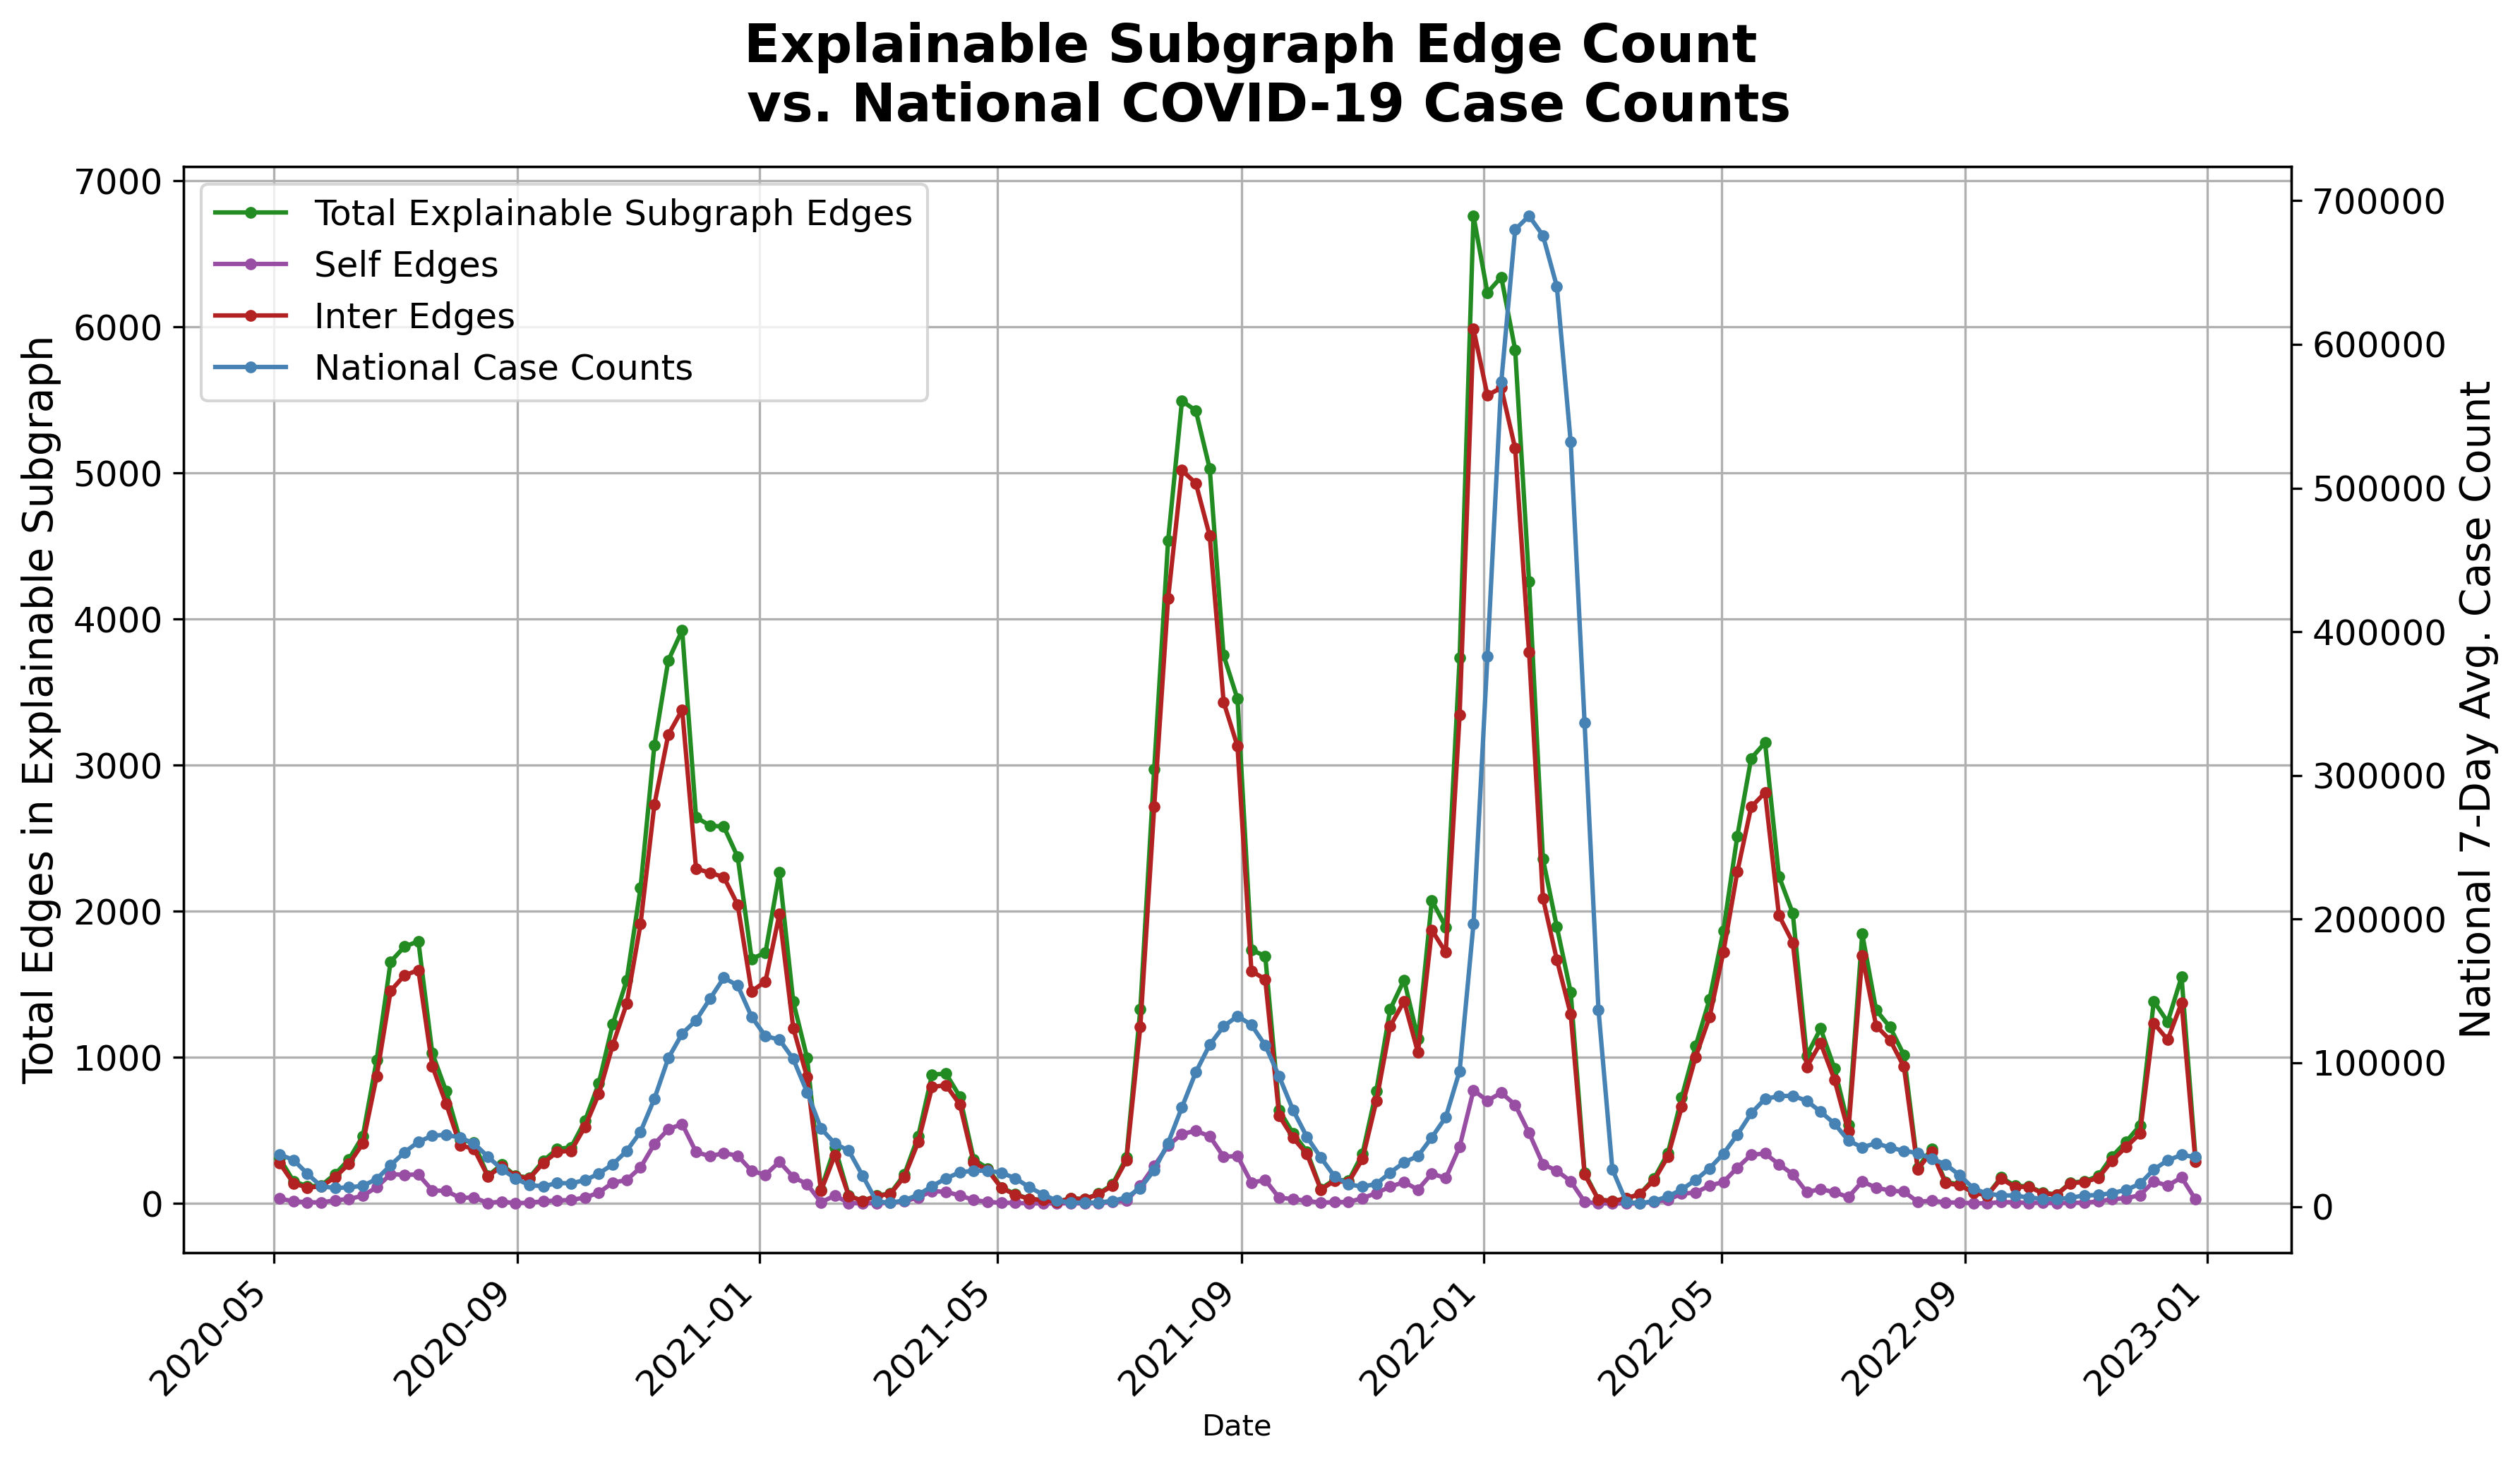

In [33]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

sub_case_df = case_df.loc[case_df['date'].isin(explain_dates)].groupby('date')[['CASE_COUNT_7DAY_AVG']].sum().reset_index()

line1, = ax.plot(explain_count_df['date'], explain_count_df['total_edge_count'], '.-', label='Total Explainable Subgraph Edges', color='forestgreen')
line2, = ax.plot(explain_count_df['date'], explain_count_df['self_edge_count'], '.-', label='Self Edges', color='#984ea3')
line3, = ax.plot(explain_count_df['date'], explain_count_df['inter_edge_count'], '.-', label='Inter Edges', color='firebrick')

ax.set_ylabel('Total Edges in Explainable Subgraph', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')

ax2 = ax.twinx()
line4, = ax2.plot(
    sub_case_df['date'],
    sub_case_df['CASE_COUNT_7DAY_AVG'],
    ".-",
    color='steelblue',
    label='National Case Counts' # More descriptive label
)
ax2.set_ylabel('National 7-Day Avg. Case Count', fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)

ax.legend(handles=[line1, line2, line3, line4], loc='upper left', fontsize=12)


fig.autofmt_xdate(rotation=45)
fig.suptitle('Explainable Subgraph Edge Count \n vs. National COVID-19 Case Counts',
             fontsize=18,
             fontweight='bold')

plt.tight_layout()

# plt.savefig("explain_edge_count.png")


In [34]:
weekly_counts_df = mobility_df.groupby('date_range_start').size().to_frame('weekly_count')
weekly_counts_df['5_week_rolling_sum'] = weekly_counts_df['weekly_count'].rolling(window=5).sum()

start_date = '2020-05-04'
weekly_counts_df = weekly_counts_df.loc[start_date:].copy()
weekly_counts_df

,weekly_count,5_week_rolling_sum
date_range_start,,
2020-05-04,4189,17546.0
2020-05-11,4385,18857.0
2020-05-18,5159,20874.0
2020-05-25,5378,22820.0
2020-06-01,5768,24879.0
...,...,...
2022-11-28,6202,34382.0
2022-12-05,6572,34393.0
2022-12-12,7047,34683.0


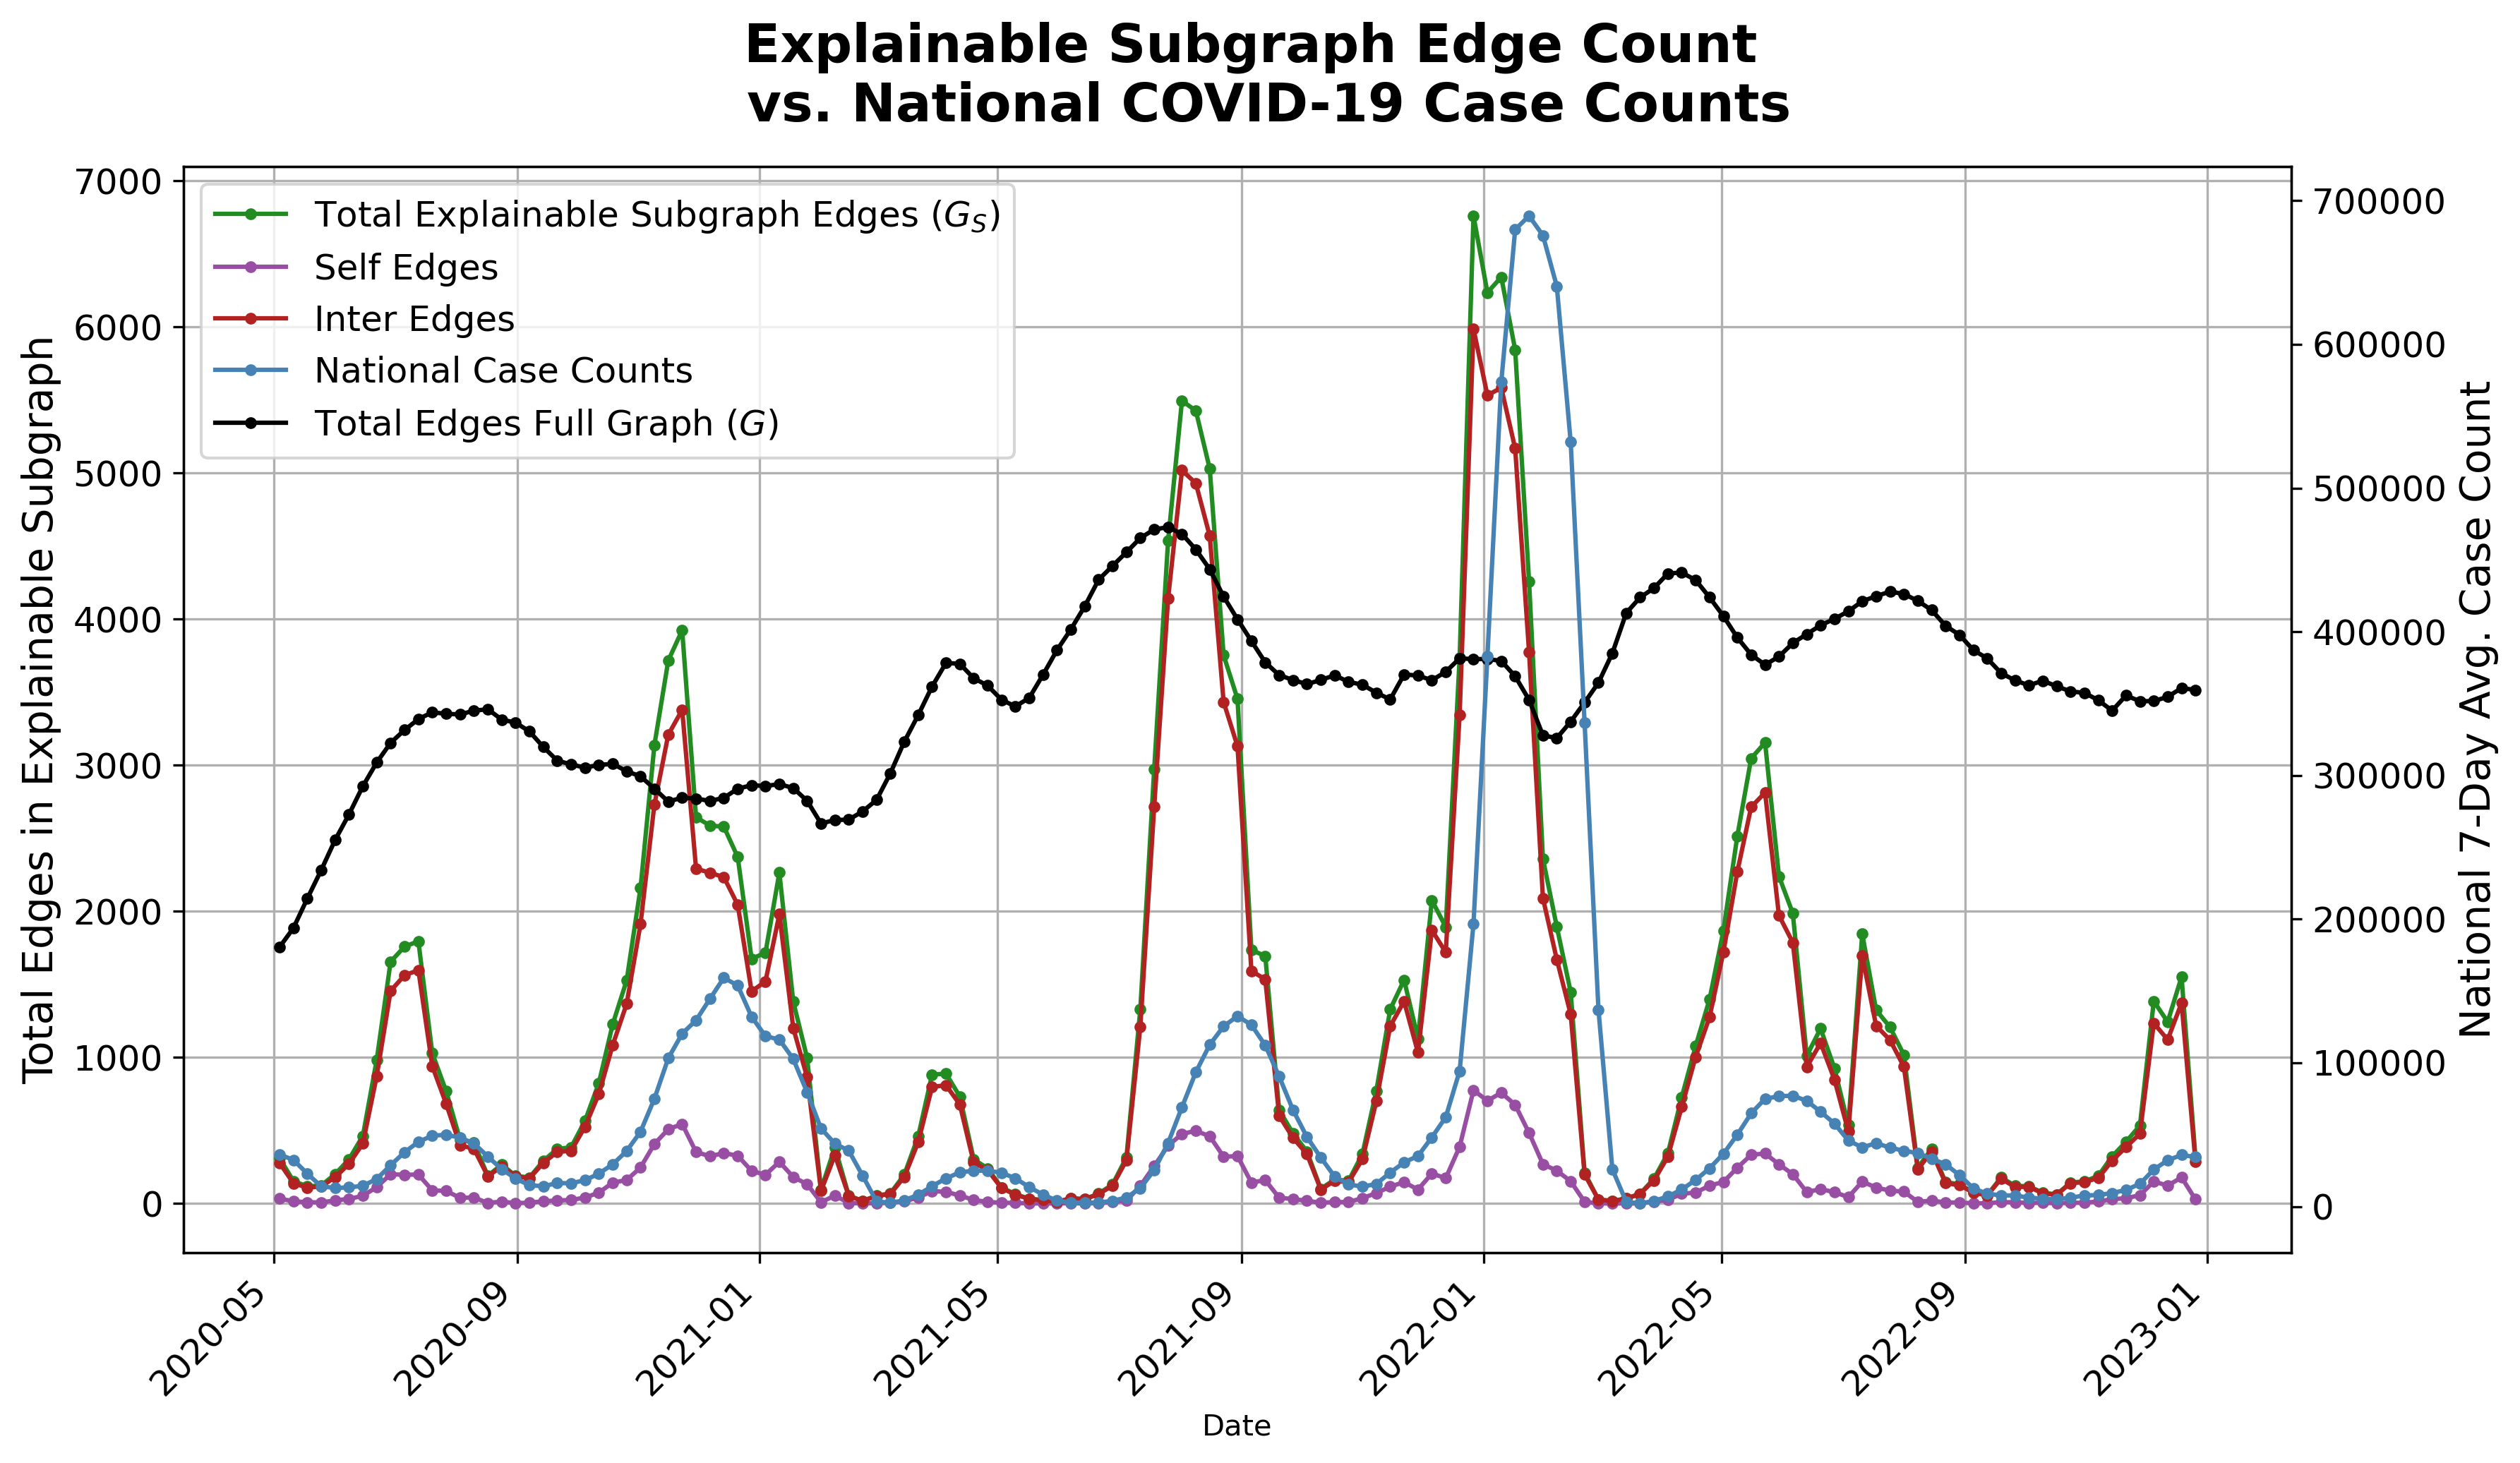

In [35]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

sub_case_df = case_df.loc[case_df['date'].isin(explain_dates)].groupby('date')[['CASE_COUNT_7DAY_AVG']].sum().reset_index()

line1, = ax.plot(explain_count_df['date'], explain_count_df['total_edge_count'], '.-', label=r'Total Explainable Subgraph Edges ($G_S$)', color='forestgreen')
line2, = ax.plot(explain_count_df['date'], explain_count_df['self_edge_count'], '.-', label='Self Edges', color='#984ea3')
line3, = ax.plot(explain_count_df['date'], explain_count_df['inter_edge_count'], '.-', label='Inter Edges', color='firebrick')

line5, = ax.plot(weekly_counts_df['5_week_rolling_sum'] / 10, '.-', label=r'Total Edges Full Graph ($G$)', color='black')

ax.set_ylabel('Total Edges in Explainable Subgraph', fontsize=14)
ax.set_xlabel('Date')
ax.grid('dashed')

ax2 = ax.twinx()
line4, = ax2.plot(
    sub_case_df['date'],
    sub_case_df['CASE_COUNT_7DAY_AVG'],
    ".-",
    color='steelblue',
    label='National Case Counts' # More descriptive label
)
ax2.set_ylabel('National 7-Day Avg. Case Count', fontsize=14)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)

ax.legend(handles=[line1, line2, line3, line4, line5], loc='upper left', fontsize=12)


fig.autofmt_xdate(rotation=45)
fig.suptitle('Explainable Subgraph Edge Count \n vs. National COVID-19 Case Counts',
             fontsize=18,
             fontweight='bold')

plt.tight_layout()



--- Computing Autocorrelation for: 'Total Explainable Subgraph Edges' ---
  * Autocorrelation at Lag 1: `0.9143`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9117`
    - Lag 2: `0.7651`
    - Lag 3: `0.5694`
    - Lag 4: `0.3564`
    - Lag 5: `0.1606`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


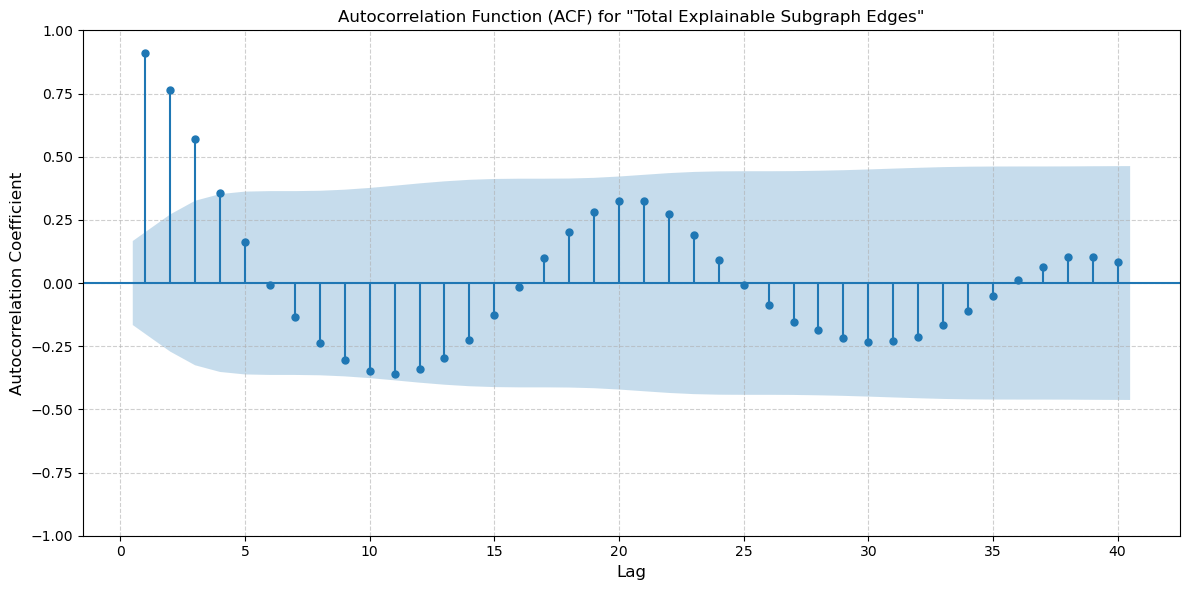


--- Computing Autocorrelation for: 'Self Edges' ---
  * Autocorrelation at Lag 1: `0.9048`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9026`
    - Lag 2: `0.7551`
    - Lag 3: `0.5610`
    - Lag 4: `0.3571`
    - Lag 5: `0.1688`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


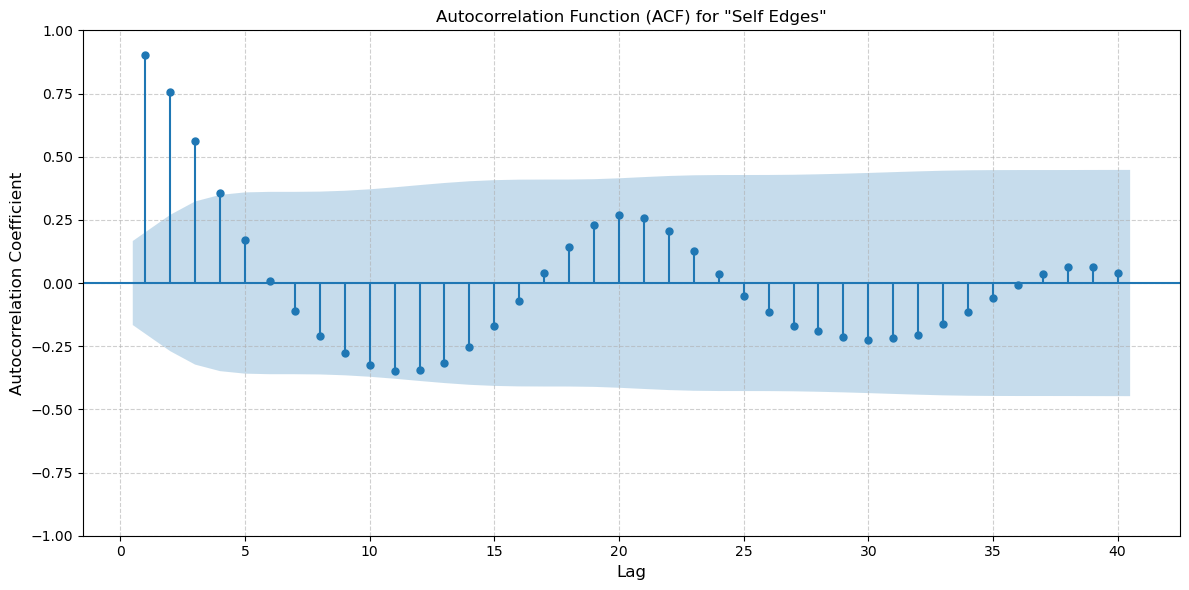


--- Computing Autocorrelation for: 'Inter Edges' ---
  * Autocorrelation at Lag 1: `0.9152`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9126`
    - Lag 2: `0.7662`
    - Lag 3: `0.5705`
    - Lag 4: `0.3569`
    - Lag 5: `0.1606`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


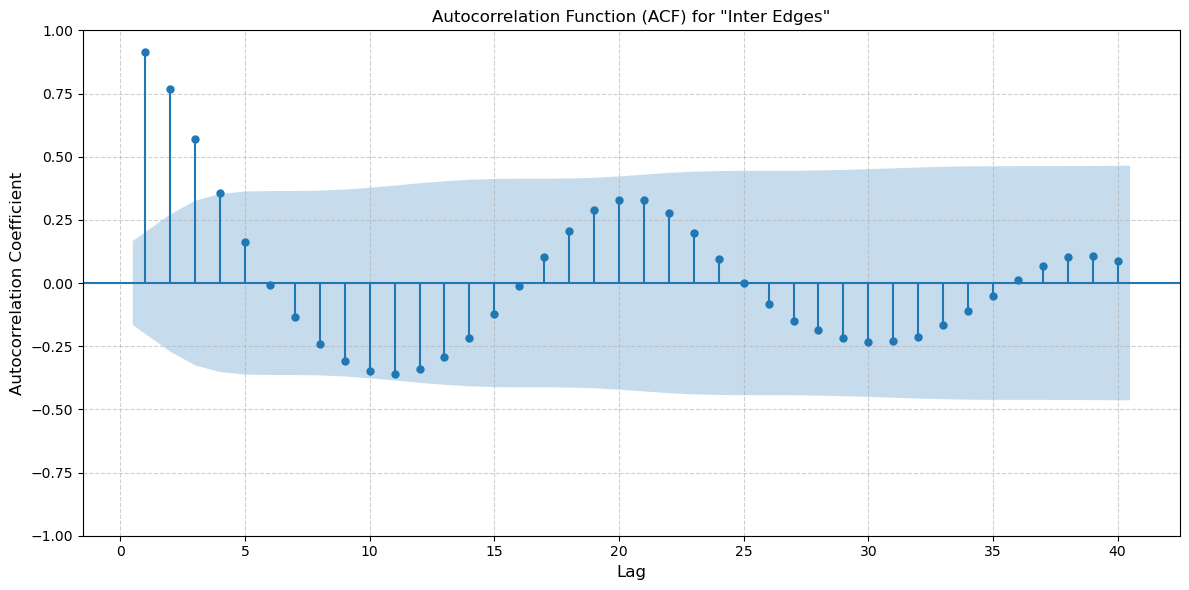


--- Computing Autocorrelation for: 'National 7-Day Avg. Case Count' ---
  * Autocorrelation at Lag 1: `0.9561`
    This value indicates the linear relationship between a data point and the data point immediately preceding it.
  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):
    - Lag 0: `1.0000`
    - Lag 1: `0.9555`
    - Lag 2: `0.8362`
    - Lag 3: `0.6704`
    - Lag 4: `0.4847`
    - Lag 5: `0.2991`
    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.


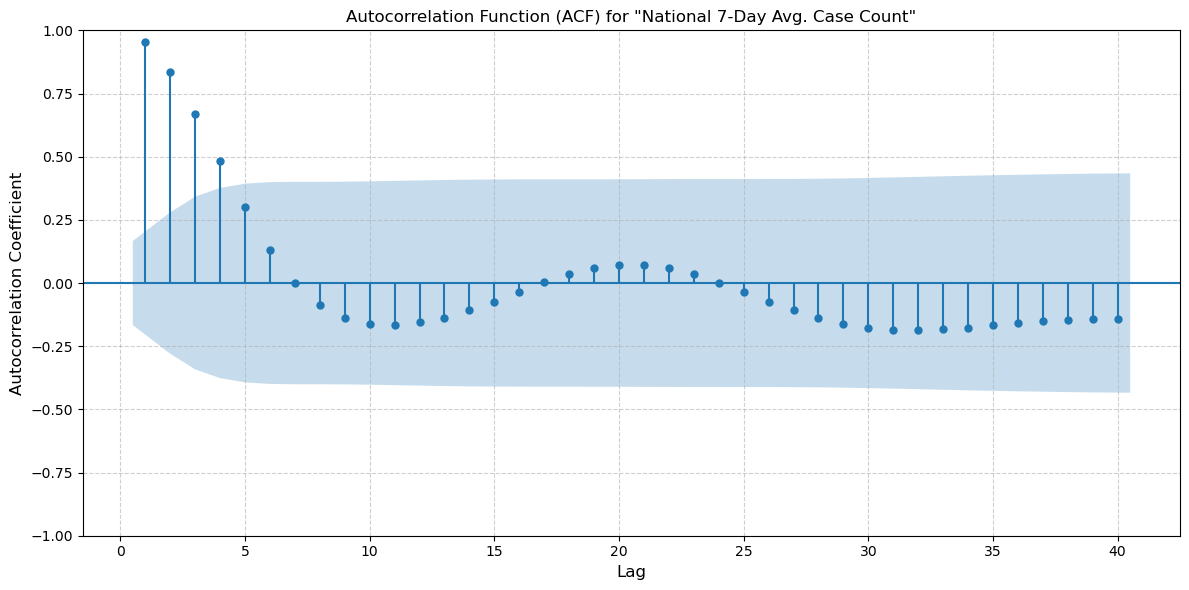

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf # For computing an array of ACF values

# Assuming explain_count_df and sub_case_df are already loaded and available in your Jupyter environment
# from the plotting cell you provided.

# Dictionary to hold the time series we want to analyze.
# We extract the relevant columns directly from your dataframes based on your plot code.
time_series_to_analyze = {
    'Total Explainable Subgraph Edges': explain_count_df['total_edge_count'],
    'Self Edges': explain_count_df['self_edge_count'],
    'Inter Edges': explain_count_df['inter_edge_count'],
    'National 7-Day Avg. Case Count': sub_case_df['CASE_COUNT_7DAY_AVG']
}

for name, series in time_series_to_analyze.items():
    print(f"\n--- Computing Autocorrelation for: '{name}' ---")

    # Before computing, let's check if the series has enough data points.
    if len(series) < 2:
        print(f"  The series '{name}' has only {len(series)} data points, which is too short to compute meaningful autocorrelation. Skipping this series.")
        continue

    # Determine a reasonable number of lags to compute for the ACF.
    # A common rule of thumb is to use `min(len(series) // 2 - 1, 40)` to avoid too many lags for shorter series
    # and to focus on the most relevant lags for longer ones.
    max_lags_for_acf = min(len(series) // 2 - 1, 40)
    if max_lags_for_acf <= 0:
        print(f"  The series '{name}' is too short ({len(series)} data points) to compute multiple lags for autocorrelation. Skipping detailed ACF analysis.")
        continue

    # 1. Compute a specific autocorrelation value (e.g., at lag 1)
    # The `.autocorr(lag=1)` method from pandas Series provides a quick way to get this.
    # This gives you a single number representing the correlation between the series and itself shifted by one period.
    autocorr_lag1 = series.autocorr(lag=1)
    print(f"  * Autocorrelation at Lag 1: `{autocorr_lag1:.4f}`")
    print(f"    This value indicates the linear relationship between a data point and the data point immediately preceding it.")


    # 2. Compute the full Autocorrelation Function (ACF) values
    # The `acf` function from `statsmodels.tsa.stattools` computes an array of autocorrelation coefficients
    # for various lags.
    #   - `nlags`: The number of lags to compute.
    #   - `fft=True`: Can speed up computation for very long series.
    #   - `unbiased=True`: Uses an unbiased estimator for the sample autocorrelation.
    #   - `alpha=0.05`: Used to return confidence intervals, which are helpful for `plot_acf`.
    acf_coefficients, confint = acf(series, nlags=max_lags_for_acf, fft=True, alpha=0.05)

    print(f"  * First 5 Autocorrelation Coefficients (including Lag 0, which is always 1):")
    for i, coeff in enumerate(acf_coefficients[:6]):
        print(f"    - Lag {i}: `{coeff:.4f}`")
    print(f"    Note: The autocorrelation at Lag 0 is always 1, as a series is perfectly correlated with itself.")


    # 3. Visualize the Autocorrelation Function (ACF) plot
    # This is the most common and intuitive way to inspect autocorrelation across many lags.
    # The `plot_acf` function from `statsmodels.graphics.tsaplots` generates this plot.
    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    plot_acf(series, lags=max_lags_for_acf, ax=ax,
             title=f'Autocorrelation Function (ACF) for "{name}"',
             alpha=0.05, # Alpha for the confidence interval band (typically 95% CI)
             zero=False # Exclude lag 0 from the plot, as it's always 1 and can obscure other lags
            )
    ax.set_xlabel("Lag", fontsize=12)
    ax.set_ylabel("Autocorrelation Coefficient", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [43]:
from scipy import signal


time_series_to_analyze = {
    'Total Explainable Subgraph Edges': explain_count_df['total_edge_count'],
    'Self Edges': explain_count_df['self_edge_count'],
    'Inter Edges': explain_count_df['inter_edge_count'],
}

y = sub_case_df['CASE_COUNT_7DAY_AVG']

for name, x in time_series_to_analyze.items():
    
    correlation = signal.correlate(x-np.mean(x), y - np.mean(y), mode="full")
    lags = signal.correlation_lags(len(x), len(y), mode="full")
    lag = lags[np.argmax(abs(correlation))]
    print(lag)

-3
-3
-3


In [44]:
lags

array([-138, -137, -136, -135, -134, -133, -132, -131, -130, -129, -128,
       -127, -126, -125, -124, -123, -122, -121, -120, -119, -118, -117,
       -116, -115, -114, -113, -112, -111, -110, -109, -108, -107, -106,
       -105, -104, -103, -102, -101, -100,  -99,  -98,  -97,  -96,  -95,
        -94,  -93,  -92,  -91,  -90,  -89,  -88,  -87,  -86,  -85,  -84,
        -83,  -82,  -81,  -80,  -79,  -78,  -77,  -76,  -75,  -74,  -73,
        -72,  -71,  -70,  -69,  -68,  -67,  -66,  -65,  -64,  -63,  -62,
        -61,  -60,  -59,  -58,  -57,  -56,  -55,  -54,  -53,  -52,  -51,
        -50,  -49,  -48,  -47,  -46,  -45,  -44,  -43,  -42,  -41,  -40,
        -39,  -38,  -37,  -36,  -35,  -34,  -33,  -32,  -31,  -30,  -29,
        -28,  -27,  -26,  -25,  -24,  -23,  -22,  -21,  -20,  -19,  -18,
        -17,  -16,  -15,  -14,  -13,  -12,  -11,  -10,   -9,   -8,   -7,
         -6,   -5,   -4,   -3,   -2,   -1,    0,    1,    2,    3,    4,
          5,    6,    7,    8,    9,   10,   11,   

### Explainable subplot animation

In [ ]:
from matplotlib.animation import FuncAnimation


land_color = '#f5f5f5'
geodetic = ccrs.Geodetic()
platecarree = ccrs.PlateCarree()

def update(frame_num, target_date, ax, dates, df, sm, cbar_ax, frame_artists):
    """
    The function that draws each frame of the animation.
    'frame_num' is the frame number, provided by FuncAnimation.
    """
    # Clear artists from the previous frame (arrows and colorbar)
    for artist in frame_artists:
        artist.remove()
    frame_artists.clear()
    
    if cbar_ax:
        cbar_ax.clear()

    # Get the data for the current frame
    current_date = dates[frame_num]
    subset_df = df[df['date_range_start'] == current_date].sort_values('log_visitor_home_aggregation')
    
    if subset_df.empty:
        ax.set_title(f"Explainable Mobility\n{current_date.strftime('%Y-%m-%d')} (No Data)", fontsize=12)
        return ax.artists # Return the list of artists

    # --- Plot Mobility Data for the current frame ---
    for _, row in subset_df.iterrows():
        lon_orig, lat_orig = row['LONGITUDE_orig'], row['LATITUDE_orig']
        lon_dest, lat_dest = row['LONGITUDE_dest'], row['LATITUDE_dest']
        mob = row['log_visitor_home_aggregation']
        color = sm.to_rgba(mob)
        
        # Scale linewidth based on mobility value
        linewidth = np.sqrt(max(0, mob - df['log_visitor_home_aggregation'].min() + 1)) * 0.5
        linewidth = max(0.1, linewidth)

        # Use annotate to draw arrows
        arrow_artist = ax.annotate(
            '',
            xy=(lon_dest, lat_dest),
            xycoords=platecarree,
            xytext=(lon_orig, lat_orig),
            textcoords=platecarree,
            arrowprops=dict(
                arrowstyle="->",
                color=color,
                lw=linewidth,
                alpha=0.8,
                shrinkA=1, shrinkB=5
            ),
            zorder=7,
        )

        frame_artists.append(arrow_artist)

    # --- Update Title and Colorbar ---
    ax.set_title(f"Explainable Subgraph \nTarget date: {target_date} Time slice: {current_date.strftime('%Y-%m-%d')}", fontsize=12)
    
    # Re-draw the colorbar for the current frame
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label(r'$\log_{10}$ Visitor Home Aggregation', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    return frame_artists


# --- Main Loop to Generate Animations ---
swapped_dict = {value: key for key, value in node_dict.items()}

for target_date, subgraph_edges in explaination_dict.items():
    print(f"Processing animation for target_date: {target_date}")

    # Create keys to filter the main mobility dataframe
    node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
    node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
    explainable_keys = [f"{start}-{end}" for start, end in zip(node_idx_start, node_idx_end)]
    explainable_mobility_df = mobility_df[mobility_df["key"].isin(explainable_keys)].copy()
    
    # Convert dates if they are not already datetime objects
    explainable_mobility_df["date_range_start"] = pd.to_datetime(explainable_mobility_df["date_range_start"])
    dates = sorted(explainable_mobility_df["date_range_start"].unique())
    
    if not dates:
        print(f"Skipping {target_date} - no data found.")
        continue

    # --- One-Time Plot Setup ---
    fig = plt.figure(figsize=(12, 8), dpi=200)
    ax = fig.add_subplot(1, 1, 1, projection=platecarree)
    ax.set_extent([-130, -65, 23, 50], platecarree)

    # Add static geographic features
    ax.add_feature(cfeature.LAND, facecolor=land_color, zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'], zorder=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=3)

    # --- Setup Color Mapping ---
    # Normalize across the entire dataset for this target_date for a consistent colorbar
    min_val = explainable_mobility_df['log_visitor_home_aggregation'].min()
    max_val = explainable_mobility_df['log_visitor_home_aggregation'].max()
    norm = plt.Normalize(vmin=min_val, vmax=max_val)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])

    # Create an axes for the colorbar so we can clear and redraw it
    cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5]) # [left, bottom, width, height]

    frame_artists = []
    # --- Create and Save the Animation ---
    ani = FuncAnimation(
        fig, 
        update, 
        frames=len(dates), 
        fargs=(target_date, ax, dates, explainable_mobility_df, sm, cbar_ax, frame_artists),
        interval=1000, 
        repeat=False
    )
    
    # Save the animation
    output_filename = f'animation_{target_date}.gif'
    print(f"Saving animation to {output_filename}...")
    ani.save(output_filename, writer='imagemagick')
    print("Save complete.")
    plt.close(fig) # Close the figure to free up memory

In [ ]:
# --- Assume these variables are pre-defined ---
# explaination_dict, node_dict, mobility_df
# case_df: Your DataFrame with CBSA case counts

# --- NEW SETUP: Load CBSA Geometries ---
### Provide the path to the .shp file you downloaded
cbsa_shapefile_path = '../assets/tl_2024_us_cbsa/tl_2024_us_cbsa.shp' 

try:
    cbsa_reader = shpreader.Reader(cbsa_shapefile_path)
    # Create a dictionary mapping CBSA code (GEOID) to its geometry
    # This makes lookups much faster inside the animation loop
    cbsa_geometries = {
        rec.attributes['GEOID']: rec.geometry for rec in cbsa_reader.records()
    }
    print(f"Successfully loaded {len(cbsa_geometries)} CBSA shapes.")
except Exception as e:
    print(f"Error loading shapefile: {e}")
    print("Please ensure the path is correct and the shapefile exists.")
    cbsa_geometries = {} # Set to empty to avoid further errors

# Prepare the case data
# Ensure date column is in datetime format
# The column name 'date' is assumed from your DataFrame snippet
case_df['date_range_start'] = pd.to_datetime(case_df['date'])

# --- Constants ---
land_color = '#f5f5f5'
geodetic = ccrs.Geodetic()
platecarree = ccrs.PlateCarree()


### MODIFIED: Update function now handles heatmap_artists as well
def update(frame_num, ax, dates, target_date, mobility_df, case_df, sm_mobility, sm_cases, 
           cbar_ax_mobility, cbar_ax_cases, arrow_artists, heatmap_artists):
    """
    The function that draws each frame of the animation.
    """
    # Clear artists from the previous frame
    for artist in arrow_artists:
        artist.remove()
    arrow_artists.clear()
    
    ### NEW: Clear heatmap shapes from the previous frame
    for artist in heatmap_artists:
        artist.remove()
    heatmap_artists.clear()
    
    # Clear colorbars
    if cbar_ax_mobility: cbar_ax_mobility.clear()
    if cbar_ax_cases: cbar_ax_cases.clear()

    # --- Get data for the current frame ---
    current_date = dates[frame_num]
    
    # --- 1. Draw the CBSA Heatmap (drawn first, so it's in the background) ---
    case_subset = case_df[case_df['date_range_start'] == current_date]
    if not case_subset.empty and cbsa_geometries:
        for _, row in case_subset.iterrows():
            cbsa_code = str(row['CBSA']) # Ensure CBSA code is a string
            case_count = row['CASE_COUNT_7DAY_AVG']
            
            if cbsa_code in cbsa_geometries:
                geom = cbsa_geometries[cbsa_code]
                color = sm_cases.to_rgba(case_count)
                
                # Add the colored CBSA shape to the map
                shape_artist = ax.add_geometries(
                    [geom], crs=platecarree, facecolor=color,
                    edgecolor='gray', linewidth=0.2, zorder=5
                )
                heatmap_artists.append(shape_artist)

    # --- 2. Draw Mobility Arrows ---
    mobility_subset = mobility_df[mobility_df['date_range_start'] == current_date]
    if not mobility_subset.empty:
        for _, row in mobility_subset.iterrows():
            lon_orig, lat_orig = row['LONGITUDE_orig'], row['LATITUDE_orig']
            lon_dest, lat_dest = row['LONGITUDE_dest'], row['LATITUDE_dest']
            mob = row['log_visitor_home_aggregation']
            color = sm_mobility.to_rgba(mob)
            linewidth = np.sqrt(max(0, mob - mobility_df['log_visitor_home_aggregation'].min() + 1)) * 0.5
            
            arrow_artist = ax.annotate(
                '', xy=(lon_dest, lat_dest), xycoords=platecarree,
                xytext=(lon_orig, lat_orig), textcoords=platecarree,
                arrowprops=dict(
                    arrowstyle="->", color=color, lw=max(0.1, linewidth),
                    alpha=0.8, shrinkA=1, shrinkB=5
                ),
                zorder=7, # Higher zorder to draw on top of the heatmap
            )
            arrow_artists.append(arrow_artist)

    # --- 3. Update Titles and Colorbars ---
    ax.set_title(f"Explainable Subgraph \nTarget date: {target_date} Time slice: {current_date.strftime('%Y-%m-%d')}", fontsize=12)

    # Redraw mobility colorbar
    cbar_mob = plt.colorbar(sm_mobility, cax=cbar_ax_mobility, orientation='vertical')
    cbar_mob.set_label(r'$\log_{10}$ Visitor Aggregation', fontsize=10)
    cbar_mob.ax.tick_params(labelsize=8)
    
    # Redraw cases colorbar
    cbar_case = plt.colorbar(sm_cases, cax=cbar_ax_cases, orientation='vertical')
    cbar_case.set_label('7-Day Avg Case Count', fontsize=10)
    cbar_case.ax.tick_params(labelsize=8)

    cbar_case.ax.yaxis.set_ticks_position('left')
    cbar_case.ax.yaxis.set_label_position('left')

    return arrow_artists + heatmap_artists


# --- Main Loop ---
swapped_dict = {value: key for key, value in node_dict.items()}

for target_date, subgraph_edges in explaination_dict.items():
    print(f"Processing animation for target_date: {target_date}")

    node_idx_start = [swapped_dict[item] for item in subgraph_edges[0,:].cpu().numpy()]
    node_idx_end = [swapped_dict[item] for item in subgraph_edges[1,:].cpu().numpy()]
    explainable_keys = [f"{start}-{end}" for start, end in zip(node_idx_start, node_idx_end)]
    explainable_mobility_df = mobility_df[mobility_df["key"].isin(explainable_keys)].copy()
    explainable_mobility_df["date_range_start"] = pd.to_datetime(explainable_mobility_df["date_range_start"])
    dates = sorted(explainable_mobility_df["date_range_start"].unique())
    
    if not dates:
        print(f"Skipping {target_date} - no data found.")
        continue

    # --- One-Time Plot Setup ---
    fig = plt.figure(figsize=(14, 8), dpi=200)
    ax = fig.add_subplot(1, 1, 1, projection=platecarree)
    ax.set_extent([-130, -65, 23, 50], platecarree)
    ax.add_feature(cfeature.LAND, facecolor=land_color, zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'], zorder=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=3)

    # --- Setup Color Mapping for BOTH datasets ---
    # Mobility Color Scale
    norm_mob = plt.Normalize(vmin=explainable_mobility_df['log_visitor_home_aggregation'].min(), 
                             vmax=explainable_mobility_df['log_visitor_home_aggregation'].max())
    sm_mobility = plt.cm.ScalarMappable(cmap='viridis', norm=norm_mob)
    sm_mobility.set_array([])

    # Cases Color Scale (using LogNorm for better visualization of outbreaks)
    # Using a small epsilon to avoid log(0)
    norm_cases = plt.Normalize(vmin=case_df['CASE_COUNT_7DAY_AVG'].min(), 
                               vmax=case_df['CASE_COUNT_7DAY_AVG'].max())
    sm_cases = plt.cm.ScalarMappable(cmap='Reds', norm=norm_cases)
    sm_cases.set_array([])

    # --- Setup Axes for TWO Colorbars ---
    cbar_ax_mobility = fig.add_axes([0.91, 0.25, 0.02, 0.5])
    cbar_ax_cases = fig.add_axes([0.07, 0.25, 0.02, 0.5])

    # --- Create lists to hold artists for each frame ---
    arrow_artists = []
    heatmap_artists = [] ### NEW list for heatmap shapes

    # --- Create Animation ---
    ani = FuncAnimation(
        fig, 
        update, 
        frames=len(dates), 
        fargs=(ax, dates, target_date, explainable_mobility_df, case_df, sm_mobility, sm_cases,
               cbar_ax_mobility, cbar_ax_cases, arrow_artists, heatmap_artists),
        interval=100, 
        repeat=False
    )
    
    output_filename = f'animation_with_heatmap_{target_date}.gif'
    print(f"Saving animation to {output_filename}...")
    ani.save(output_filename) 
    print("Save complete.")
    plt.close(fig)

# GCN Tuned Hyperparams

In [ ]:
import pandas as pd

gcn_results = pd.read_csv("experiments/cgnn/results.csv")

gcn_results.iloc[gcn_results.test_loss.idxmin()]

In [ ]:
import seaborn as sns

dropout_plot = sns.violinplot(data=gcn_results, x="dropout", y="test_loss").set_title('GCN Hyperparameter Tuning')
dropout_plot.get_figure().savefig("../assets/dropout.png") 

In [ ]:
base_lr_plot = sns.violinplot(data=gcn_results, x="base_lr", y="test_loss").set_title('GCN Hyperparameter Tuning')
base_lr_plot.get_figure().savefig("../assets/base_lr.png") 

In [ ]:
weight_decay_plot = sns.violinplot(data=gcn_results, x="weight_decay", y="test_loss").set_title('GCN Hyperparameter Tuning')
weight_decay_plot.get_figure().savefig("../assets/weight_decay.png") 

In [ ]:
from tqdm import tqdm
from model import GCN, RMSLELoss
from torch_geometric.nn import summary

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
graph = process_data.create_torch_geometric_data("gcn", device)

model     = GCN(dropout=0.1).to(device)
print(summary(model, graph.x, graph.edge_index))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = RMSLELoss()

def train():
	model.train()
	optimizer.zero_grad()
	out, _ = model(graph.x.to(device), graph.edge_index.to(device))
	loss = criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask])
	loss.backward()
	optimizer.step()
	return loss

def test():
	model.eval()
	out, _  = model(graph.x, graph.edge_index)
	loss = criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask])

	return loss

train_loss = []
test_loss = []
for epoch in tqdm(range(100_000)):
	loss = train()
	train_loss.append(loss.cpu().detach().numpy())
	loss = test()
	test_loss.append(loss.cpu().detach().numpy())

print("final test loss: {}".format(test_loss[-1]))

In [ ]:
model.eval()
out, _  = model(graph.x, graph.edge_index)
print("train loss", criterion(out[graph.train_mask].squeeze(), graph.y[graph.train_mask]))
print("test loss", criterion(out[graph.test_mask].squeeze(), graph.y[graph.test_mask]))
print("train corr", torch.corrcoef(torch.stack((out[graph.train_mask].squeeze(), graph.y[graph.train_mask])))[0,1])
print("test corr", torch.corrcoef(torch.stack((out[graph.test_mask].squeeze(), graph.y[graph.test_mask])))[0,1])
y_test = graph.y[graph.test_mask].cpu().numpy()
out_test = out[graph.test_mask].detach().cpu().numpy()

y_train = graph.y[graph.train_mask].cpu().numpy()
out_train = out[graph.train_mask].detach().cpu().numpy()

In [ ]:
# predict case delta metrics
delta_data = process_data.create_torch_geometric_data("gcn_delta", device, predict_delta=True)

model.eval()
_, delta_pred  = model(graph.x, graph.edge_index)
print("train loss", criterion(torch.abs(delta_pred[graph.train_mask].squeeze()), torch.abs(delta_data.y[graph.train_mask])))
print("test loss", criterion(torch.abs(delta_pred[graph.test_mask].squeeze()), torch.abs(delta_data.y[graph.test_mask])))
print("train corr", torch.corrcoef(torch.stack((delta_pred[graph.train_mask].squeeze(), delta_data.y[graph.train_mask])))[0,1])
print("test corr", torch.corrcoef(torch.stack((delta_pred[graph.test_mask].squeeze(), delta_data.y[graph.test_mask])))[0,1])

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train_loss, label='training loss')
ax.plot(test_loss, label='validation loss')
ax.set_xlabel('step')
ax.set_ylabel('RMSLE')
ax.grid()
ax.legend()

fig.suptitle("GCN train and val RMSLE")
fig.savefig("../assets/gcn_train.png")

In [ ]:
import pandas as pd
import numpy as np

from utils import get_fips_list
from codebook import BOROUGH_FULL_FIPS_DICT

fips_list = get_fips_list()

node_dict = process_data.create_node_key()

pred_df = pd.DataFrame()
pred_df['key'] = np.array(list(node_dict.keys()))[np.where(np.array(graph.test_mask.cpu().numpy())==1)]
pred_df['truth'] = y_test
pred_df['pred'] = out_test

pred_df[['fips','date']] = pred_df['key'].str.split('-',n=1, expand=True)
pred_df['date'] = pd.to_datetime(pred_df['date'])

train_df = pd.DataFrame()
train_df['key'] = np.array(list(node_dict.keys()))[np.where(np.array(graph.train_mask.cpu().numpy())==1)]
train_df['truth'] = y_train
train_df['pred'] = out_train

train_df[['fips','date']] = train_df['key'].str.split('-',n=1, expand=True)
train_df['date'] = pd.to_datetime(train_df['date'])


fig, ax = plt.subplots(5, figsize=(12,15), sharex=True)

for i, f in enumerate(fips_list):
    ax[i].plot(pred_df.loc[pred_df['fips'] == str(f), 'date'], pred_df.loc[pred_df['fips'] == str(f), 'pred'].values, '.-.', label='GCN prediction')
    ax[i].plot(pred_df.loc[pred_df['fips'] == str(f), 'date'], pred_df.loc[pred_df['fips'] == str(f), 'truth'].values, '-', label='truth')

    ax[i].plot(train_df.loc[train_df['fips'] == str(f), 'date'], train_df.loc[train_df['fips'] == str(f), 'pred'].values, '.-.', label='GCN train prediction')
    ax[i].plot(train_df.loc[train_df['fips'] == str(f), 'date'], train_df.loc[train_df['fips'] == str(f), 'truth'].values, '-', label='truth')
    
    ax[i].grid()
    ax[i].legend()
    ax[i].set_title(BOROUGH_FULL_FIPS_DICT[f])
    ax[i].set_ylabel(r'i(t+1)')

plt.xticks(rotation=45)
